# Baseline experiments for the diploma thesis
author: Lubojacky Jan (lubojjan@fel.cvut.cz)

In [48]:
import numpy as np
import polars as pl
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_validate, cross_val_predict, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score, make_scorer

import seaborn as sn
import matplotlib.pyplot as plt

# Loading & preprocessing the data

In [2]:
# loading data
RNA = pl.read_csv("data/200625_allRNA_fromRNAseq_annot_hg38.tsv", separator="\t")
circRNA = pl.read_csv("data/200625_circRNA_fromRNAseq_annot_hg19.tsv", separator="\t",  null_values=["NA"])
piRNA = pl.read_excel("data/piRNA_counts.xlsx", engine="xlsx2csv")
miRNA = pl.read_excel("data/final_all_samples_miRNA_seq.xlsx", engine="xlsx2csv")
sampleSheet = pl.read_excel("data/sample sheet for CVUT.xlsx", engine="xlsx2csv")

In [3]:
# find names which are both in RNA and sample sheet
sampleSheet_names = sampleSheet["SAMPLE_NAME"].to_list()
RNA_names = RNA.columns

print(sampleSheet_names)
print(RNA_names)

# find names which are both in sampleSheet_names and RNA_names
common_names = list(set(sampleSheet_names) & set(RNA_names))
common_names.sort()
print("Number of common names: ", len(common_names))
print(common_names)

# show non-common names
print("Non-common names in RNA: ", list(set(RNA_names) - set(common_names)))

['N54_S14', 'N58_S18', 'N60_S15', 'N70_S16', 'N82_S1', 'N83_S3', 'N84_S4', 'N85_S19', 'N86_S13', 'N87_S20', 'NV1428_S3', 'NV911_S19', 'NV912_S20', 'V1776_S9', 'V2110_S16', 'V2224_S17', 'V2241_S15', 'V2248_S18', 'V2322_S20', 'V2414_S25', 'V630_S11', 'V1528_S12', 'V1860_S18', 'V2133_S43', 'V1505_S10', 'V1591_S14', 'V456_S4', 'V513_S16', 'V637_S21', 'V1874_S1', 'V777_S20', 'V1800_S1', 'V359_S3', 'V382_S22', 'V406_S18', 'V220_S6', 'V2286_S1', 'V716_S1', 'V806_S1', 'V888_S2', 'V956_S6', 'V125_S5', 'V1321_S4', 'V1788_S2', 'V1456_S13', 'V108_S5', 'V624_S15', 'V1048_S12', 'V2368_S3', 'V1565_S13', 'V1422_S6', 'V1708_S22', 'V1920_S14', 'V2089_S9', 'V2284_S4', 'V2378_S5', 'V553_S11', 'V1699_S2', 'V1742_S5', 'V1823_S7', 'V1834_S7', 'V2092_S3', 'V344_S16', 'V67_S6', 'V883_S4', 'V940_S8', 'V712_S22', 'V1279_S21', 'V148_S10', 'V2278_S19', 'V1857_S8', 'V1664_S23', 'V480_S7', 'V100_S45', 'V2115_S9', 'V538_S12', 'V76_S21', 'V839_S17', 'V1744_S46', 'V2147_S10', 'V2179_S11', 'V1441_S2', 'V1592_S5', 'V1689

In [5]:
sampleSheet.head()

SAMPLE_NAME,GROUP,1 disease,2 risk,3 mutations (SF3B1only_wt),RUN,PLATFORM,N_UNIQ_MAP_READS,UNIQ_MAP
str,str,i64,i64,i64,str,str,i64,f64
"""N54_S14""","""CTR""",1,0,0,"""19_03_17""","""HiSeq""",70427795,90.56
"""N58_S18""","""CTR""",1,0,0,"""19_08_12""","""NovaSeq""",68450889,89.41
"""N60_S15""","""CTR""",1,0,0,"""19_08_12""","""NovaSeq""",78931939,87.3
"""N70_S16""","""CTR""",1,0,0,"""19_08_12""","""NovaSeq""",80070799,87.48
"""N82_S1""","""CTR""",1,0,0,"""19_01_21""","""HiSeq""",59676688,86.17


**Create input data**
- each row in RNA_X is one sample
- and we have the labels for 3 classification tasks, binary disease, 3-class risk and 3-class mutation

In [35]:
RNA_X = (RNA.lazy()
         .select(common_names)
         .collect()).to_numpy().T

print(RNA_X)

y = (sampleSheet.lazy()
    .filter(pl.col('SAMPLE_NAME').is_in(common_names))
    .sort("SAMPLE_NAME")
    .select(["1 disease", "2 risk", "3 mutations (SF3B1only_wt)"])
    .collect()).to_numpy()
y_disease, y_risk, y_mutation = y[:, 0] - 1, y[:, 1], y[:, 2] # -1 to make it 0/1 instead of 1/2

[[ 89 407   6 ...   0  96 165]
 [ 55 235   9 ...   0  55 159]
 [ 79 244  70 ...   0  85 136]
 ...
 [ 48 474  18 ...   3  37 210]
 [ 31 364  10 ...   0   2  21]
 [ 44 176   0 ...   8   0 112]]


**Data exploration / visualization with PCA**

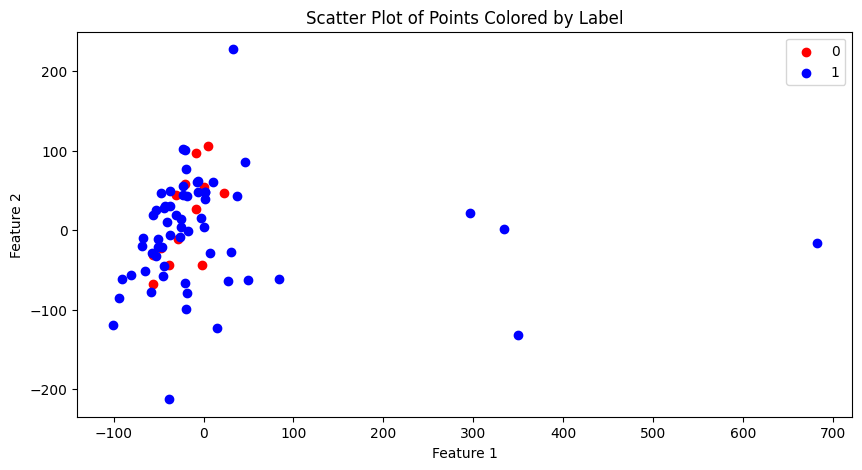

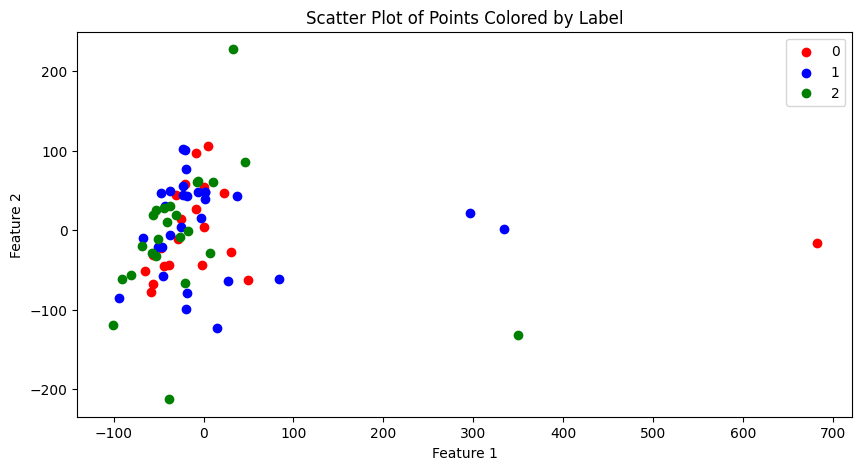

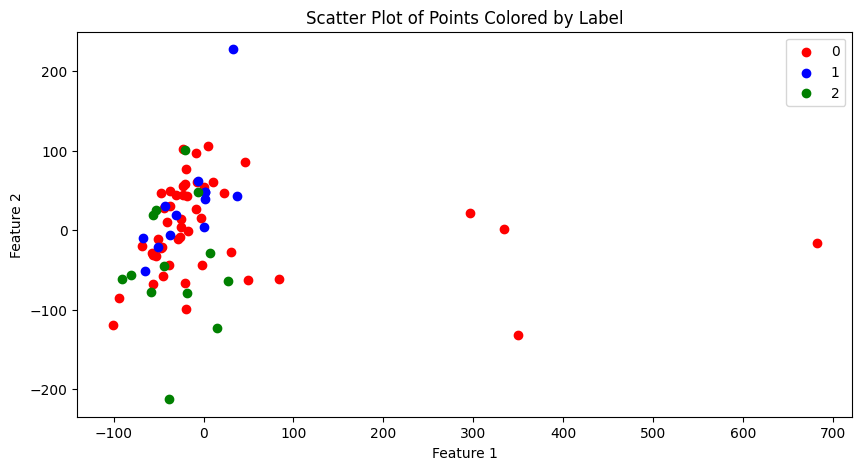

In [42]:
scaler = StandardScaler()
scaler.fit(RNA_X)
RNA_scaled = scaler.transform(RNA_X)

pca = PCA(n_components=2)
pca.fit(RNA_scaled)
RNA_pca = pca.transform(RNA_scaled)

def visualize_and_color_by_class(X, y):

    # split X by class and plot
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'black', 'yellow']
    plt.figure(figsize=(10, 5))

    for i in range(len(np.unique(y))):
        X_i = X[y == i]
        plt.scatter(X_i[:, 0], X_i[:, 1], label=str(i), color=colors[i])

    # Add labels and legend
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Scatter Plot of Points Colored by Label')
    plt.legend()

    # Show the plot
    plt.show()

visualize_and_color_by_class(RNA_pca, y_disease)
visualize_and_color_by_class(RNA_pca, y_risk)
visualize_and_color_by_class(RNA_pca, y_mutation)


# KNN

In [107]:
def KNN_evaluation(X, y, verbose=True):

    # Instantiate a KNN classifier
    knn = KNeighborsClassifier()

    # Set up the parameter grid for GridSearchCV
    param_grid = {'n_neighbors': np.arange(1, 20)}

    # Define the scoring metrics
    scoring_metrics = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'f1_weighted': 'f1_weighted',
        # 'roc_auc_macro': make_scorer(roc_auc_score, multi_class='ovo', average='macro'),
        # 'roc_auc_weighted': make_scorer(roc_auc_score, multi_class='ovo', average='weighted')
    }

    # Use GridSearchCV to find the best k
    grid_search = GridSearchCV(knn, param_grid, scoring=scoring_metrics, cv=5, refit='accuracy', n_jobs=-1)
    grid_search.fit(X, y)

    # Get the results of the grid search
    best_k = grid_search.best_params_['n_neighbors']

    # Train the model with the best k
    best_knn = KNeighborsClassifier(n_neighbors=best_k)
    # best_knn.fit(X, y)

    # Evaluate the model using cross-validation
    cv_results = cross_validate(
        best_knn, 
        X, 
        y, 
        cv=5, 
        scoring=scoring_metrics,
        n_jobs=-1
    )

    if verbose:
        # Display the results
        print("\nCross Validation Results:")
        print(f'Accuracy: {cv_results["test_accuracy"].mean():.2f} +/- {cv_results["test_accuracy"].std():.2f}')
        print(f'F1 Macro: {cv_results["test_f1_macro"].mean():.2f} +/- {cv_results["test_f1_macro"].std():.2f}')
        print(f'F1 Weighted: {cv_results["test_f1_weighted"].mean():.2f} +/- {cv_results["test_f1_weighted"].std():.2f}')
        # print(f'ROC AUC Macro: {cv_results["test_roc_auc_macro"].mean():.2f} +/- {cv_results["test_roc_auc_macro"].std():.2f}')
        # print(f'ROC AUC Weighted: {cv_results["test_roc_auc_weighted"].mean():.2f} +/- {cv_results["test_roc_auc_weighted"].std():.2f}')

    return cv_results["test_f1_weighted"].mean() + cv_results["test_accuracy"].mean() + cv_results["test_f1_macro"].mean()

In [80]:
KNN_evaluation(RNA_X, y_disease)


Cross Validation Results:
Accuracy: 0.83 +/- 0.07
F1 Macro: 0.65 +/- 0.13
F1 Weighted: 0.81 +/- 0.08


In [81]:
KNN_evaluation(RNA_X, y_risk)


Cross Validation Results:
Accuracy: 0.42 +/- 0.13
F1 Macro: 0.39 +/- 0.12
F1 Weighted: 0.40 +/- 0.11


In [82]:
KNN_evaluation(RNA_X, y_mutation)


Cross Validation Results:
Accuracy: 0.65 +/- 0.05
F1 Macro: 0.31 +/- 0.10
F1 Weighted: 0.54 +/- 0.06


## We can increase the accuracy by a significant margin using PCA to reduce the dimensionality of the data

**NOTE:** the [MoGCN](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8847688/) paper reports that using a more sophisticated DR method such as Autoencoders further increases the accuracy of the model, especially as the dimensionality of the training data increases, we could also try that later


In [108]:
scaler = StandardScaler()
scaler.fit(RNA_X)
RNA_scaled = scaler.transform(RNA_X)

best_PCA_components_disease = 1
best_disease_score = 0
best_PCA_components_risk = 1
best_risk_score = 0
best_PCA_components_mutation = 1
best_mutation_score = 0

for i in range(1, 30):
    pca = PCA(n_components=i)
    pca.fit(RNA_scaled)
    RNA_pca = pca.transform(RNA_scaled)

    score_d = KNN_evaluation(RNA_pca, y_disease, verbose=False)
    score_r = KNN_evaluation(RNA_pca, y_risk, verbose=False)
    score_m = KNN_evaluation(RNA_pca, y_mutation, verbose=False)

    if score_d > best_disease_score:
        best_PCA_components_disease = i
        best_disease_score = score_d
    if score_r > best_risk_score:
        best_PCA_components_risk = i
        best_risk_score = score_r
    if score_m > best_mutation_score:
        best_PCA_components_mutation = i
        best_mutation_score = score_m

print("Best number of PCA components for disease: ", best_PCA_components_disease)
print("Best number of PCA components for risk: ", best_PCA_components_risk)
print("Best number of PCA components for mutation: ", best_PCA_components_mutation)

Best number of PCA components for disease:  12
Best number of PCA components for risk:  29
Best number of PCA components for mutation:  11


In [110]:
# fit the KNN model again on the PCA-transformed data
pca = PCA(n_components=12)
pca.fit(RNA_scaled)
RNA_pca = pca.transform(RNA_scaled)

_ = KNN_evaluation(RNA_pca, y_disease)


Cross Validation Results:
Accuracy: 0.89 +/- 0.05
F1 Macro: 0.80 +/- 0.11
F1 Weighted: 0.89 +/- 0.06


In [118]:
# fit the KNN model again on the PCA-transformed data
pca = PCA(n_components=29)
pca.fit(RNA_scaled)
RNA_pca = pca.transform(RNA_scaled)

_ = KNN_evaluation(RNA_pca, y_risk)


Cross Validation Results:
Accuracy: 0.54 +/- 0.20
F1 Macro: 0.50 +/- 0.22
F1 Weighted: 0.51 +/- 0.21


In [116]:
# fit the KNN model again on the PCA-transformed data
pca = PCA(n_components=12)
pca.fit(RNA_scaled)
RNA_pca = pca.transform(RNA_scaled)

_ = KNN_evaluation(RNA_pca, y_mutation)


Cross Validation Results:
Accuracy: 0.65 +/- 0.03
F1 Macro: 0.26 +/- 0.01
F1 Weighted: 0.51 +/- 0.03


# SVM

# XGBoost

# Logistic regression

In [12]:
# Standardize the train and test sample
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Perform GridSearchCV to tune best-fit LR model
param = {'C': np.linspace(10**-2, 10, 30)}

In [13]:
lr_model = LogisticRegression(
    penalty='l1',
    class_weight='balanced',
    solver='liblinear'
)
gs_model = GridSearchCV(estimator=lr_model, param_grid=param)
gs_model.fit(X_std, y1)

# Train a LR model with best parameters
model = LogisticRegression(
    **gs_model.best_params_,
    penalty='l1',
    class_weight='balanced',
    solver='liblinear'
)
model.fit(X_std, y1)

LogisticRegression(C=1.3879310344827587, class_weight='balanced', penalty='l1',
                   solver='liblinear')

[0.62962963 0.9        0.94444444 0.94444444 0.94444444 0.72222222]
roc_auc: 0.85 (+/- 0.13)


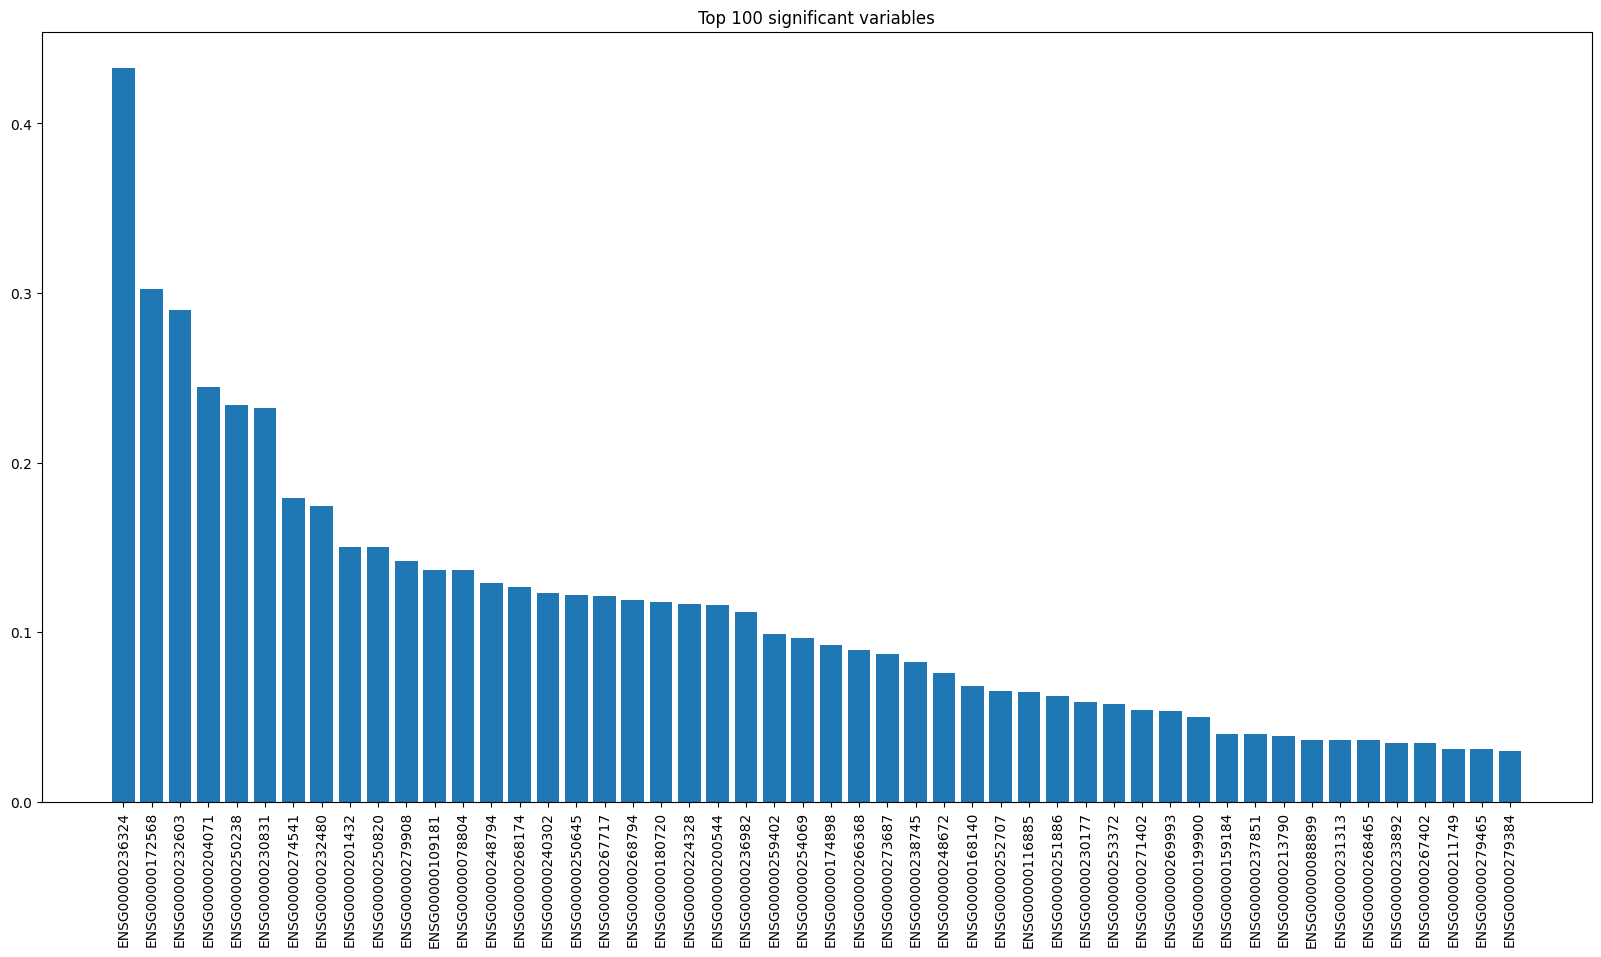

<Axes: >

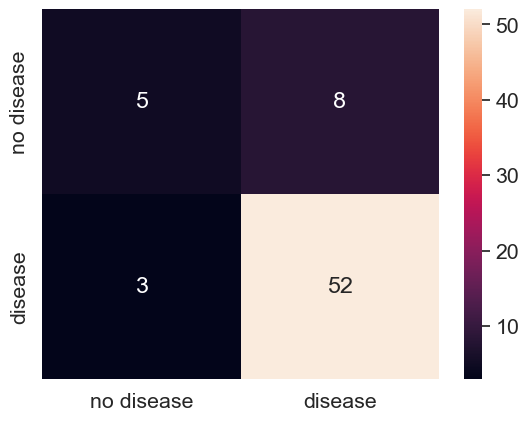

In [14]:
# perform cross-validation for the best model
lr = LogisticRegression(
    **gs_model.best_params_,
    penalty='l1',
    class_weight='balanced',
    solver='liblinear'
)
scores = cross_val_score(
    lr, X_std, y1, cv=6, scoring='roc_auc'
)
preds = cross_val_predict(
    lr, X_std, y1, cv=6, method='predict'
)
print(scores)
print("roc_auc: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std()))

features = (RNA.lazy()
            .select(["GENE_ID"])
            .collect()).to_numpy().flatten()
features

d = np.column_stack((features, abs(model.coef_[0])))
significant_varsl1 = d[d[:, 1].argsort()][::-1]
# barplot of the top 50 significant variables
plt.figure(figsize=(20, 10))
plt.bar(significant_varsl1[:50, 0], significant_varsl1[:50, 1])
plt.xticks(rotation=90)
plt.title("Top 100 significant variables")
plt.show()

# y_pred = model.predict(X_std)

cmtx = confusion_matrix(y1, preds, labels=[1, 2])

df_cm = pd.DataFrame(cmtx, columns=["no disease", "disease"])
df_cm.index = ["no disease", "disease"]
sn.set(font_scale=1.4) # for label size
sn.heatmap(df_cm, annot=True) # font size

In [16]:
# Perform GridSearchCV to tune best-fit LR model
param = {'C': np.linspace(0, 10, 5)}

lr_model = LogisticRegression(
    penalty='l1',
    class_weight='balanced',
    solver='saga',
    max_iter=200,
    tol=0.01
)
gs_model = GridSearchCV(estimator=lr_model, param_grid=param)
gs_model.fit(X_std, y2)

# Train a LR model with best parameters
model = LogisticRegression(
    **gs_model.best_params_,
    penalty='l1',
    class_weight='balanced',
    solver='saga',
    max_iter=200,
    tol=0.01
)
model.fit(X_std, y2)

/Users/lubojack/micromamba/envs/diploma/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
5 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/lubojack/micromamba/envs/diploma/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/lubojack/micromamba/envs/diploma/lib/python3.11/site-packages/sklearn/base.py", line 1145, in wrapper
    estimator._validate_params()
  File "/Users/lubojack/micromamba/envs/diploma/lib/python3.11/site-packages/sklearn/base.py", line 638, in _v

LogisticRegression(C=2.5, class_weight='balanced', max_iter=200, penalty='l1',
                   solver='saga', tol=0.01)

In [19]:
# perform cross-validation for the best model
lr = LogisticRegression(
    **gs_model.best_params_,
    penalty='l1',
    class_weight='balanced',
    solver='saga',
    max_iter=200,
    tol=0.01
)
scores = cross_val_score(
    lr, X_std, y2, cv=6, scoring='f1'
)
preds = cross_val_predict(
    lr, X_std, y2, cv=6, method='predict'
)
print(scores)
print("roc_auc: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std()))

KeyboardInterrupt: 

In [ ]:
cmtx = confusion_matrix(y, preds, labels=[1, 2, 3])

df_cm = pd.DataFrame(cmtx, columns=["risk1", "risk2", "risk3"])
df_cm.index = ["risk1", "risk2", "risk3"]
sn.set(font_scale=1.4) # for label size
sn.heatmap(df_cm, annot=True) # font size

# XGBoost